# Análisis Exploratorio de Datos
## Predicción del Resultado de Partidos de Fútbol (FTResult: H/D/A)

**Curso:** Minería de Datos (CC442) &nbsp;·&nbsp; **Fase 1 — EDA**

**Responsable:** Arbués Enrique Pérez Villegas

**Dataset:** *Club Football Match Data 2000–2025* (`adamgbor`, Kaggle). Dos tablas: `Matches.csv` (partidos) y `EloRatings.csv` (ratings Elo históricos por club).

---

Este cuaderno caracteriza el conjunto de datos antes de cualquier modelado. El objetivo no es solo describir: cada análisis busca decidir qué variables entran al modelo y cuáles se descartan. El eje que ordena todo el trabajo es la separación entre información disponible **antes** del partido (utilizable) y estadísticas registradas **después** (fuga de datos o *data leakage*). Predecir un resultado usando los goles del propio partido no tiene mérito ni validez; buena parte del EDA se dedica a identificar y aislar esas columnas.

El trabajo se enmarca en la fase de *Data Understanding* del ciclo CRISP-DM, en su especialización para predicción deportiva SRP-CRISP-DM (Bunker y Thabtah, 2019). Sobre esa base se amplían los análisis exploratorios disponibles para este dataset con una taxonomía anti-fuga de datos, la detección de atípicos multivariados por distancia de Mahalanobis, el diagnóstico de multicolinealidad mediante el factor de inflación de la varianza y un estudio condicional de la clase empate.

## 0. Configuración del entorno

Se fijan las semillas de aleatoriedad para garantizar reproducibilidad determinista (`random_state = 42` en todo el proyecto) y se definen las utilidades comunes: la carga robusta del dataset y la taxonomía de columnas que se usará de forma transversal.

In [1]:
import io
import zipfile
import urllib.request
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Carpeta de figuras para el artículo IEEE (relativa a la ubicación del notebook).
FIG_DIR = Path("../figures")
if not FIG_DIR.exists():
    FIG_DIR = Path("figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
print("Figuras se guardarán en:", FIG_DIR.resolve())

Figuras se guardarán en: /home/sergi/Documents/semesters/eight/dm/pc5/football-prediction/figures


In [2]:
def obtener_dataset() -> Path:
    # Busca una copia local (repositorio); si no existe, intenta kagglehub
    # (Colab) y, como ultimo recurso, descarga el ZIP publico del dataset.
    for c in [Path("../data/raw"), Path("data/raw"),
              Path("pc5/football-prediction/data/raw")]:
        if (c / "Matches.csv").exists():
            return c
    try:
        import kagglehub
        p = Path(kagglehub.dataset_download("adamgbor/club-football-match-data-2000-2025"))
        if (p / "Matches.csv").exists():
            return p
    except Exception:
        pass
    destino = Path("data_futbol"); destino.mkdir(exist_ok=True)
    url = ("https://www.kaggle.com/api/v1/datasets/download/"
           "adamgbor/club-football-match-data-2000-2025")
    with urllib.request.urlopen(url, timeout=180) as r:
        zipfile.ZipFile(io.BytesIO(r.read())).extractall(destino)
    return destino

RUTA = obtener_dataset()
matches = pd.read_csv(RUTA / "Matches.csv", low_memory=False, parse_dates=["MatchDate"])
elo = pd.read_csv(RUTA / "EloRatings.csv", parse_dates=["date"])
print("Matches:", matches.shape, " EloRatings:", elo.shape)

Matches: (230557, 48)  EloRatings: (245033, 4)


In [3]:
# --- Taxonomía de columnas (eje anti-leakage, usada en todo el cuaderno) ---
TARGET = "FTResult"
TARGET_ORDER = ["H", "D", "A"]

CONTEXT_COLS = ["Division", "MatchDate", "MatchTime", "HomeTeam", "AwayTeam"]
SAFE_PRE_NUMERIC = ["HomeElo", "AwayElo", "Form3Home", "Form5Home", "Form3Away", "Form5Away"]
ODDS_COLS = ["OddHome", "OddDraw", "OddAway", "MaxHome", "MaxDraw", "MaxAway",
             "Over25", "Under25", "MaxOver25", "MaxUnder25",
             "HandiSize", "HandiHome", "HandiAway"]
CLOSING_COLS = ["C_LTH", "C_LTA", "C_VHD", "C_VAD", "C_HTB", "C_PHB"]
LEAKAGE_POST = ["FTHome", "FTAway", "HTHome", "HTAway", "HTResult",
                "HomeShots", "AwayShots", "HomeTarget", "AwayTarget",
                "HomeFouls", "AwayFouls", "HomeCorners", "AwayCorners",
                "HomeYellow", "AwayYellow", "HomeRed", "AwayRed"]

def clasificar(col):
    if col == TARGET: return "TARGET"
    if col in LEAKAGE_POST: return "LEAKAGE_POST"
    if col in SAFE_PRE_NUMERIC: return "PRE_SEGURA"
    if col in ODDS_COLS: return "ODDS_MERCADO"
    if col in CLOSING_COLS: return "CIERRE_BOOKMAKER"
    if col in CONTEXT_COLS: return "CONTEXTO"
    return "SIN_CLASIFICAR"

CLASS_COLOR = {"H": "#2ca02c", "D": "#7f7f7f", "A": "#d62728"}
CLASS_LABEL = {"H": "Local (H)", "D": "Empate (D)", "A": "Visita (A)"}

# Variables derivadas que usará el modelado; se calculan una vez.
matches["elo_diff"] = matches["HomeElo"] - matches["AwayElo"]
matches["form3_diff"] = matches["Form3Home"] - matches["Form3Away"]
matches["form5_diff"] = matches["Form5Home"] - matches["Form5Away"]

## 1. Descripción del dataset y diccionario de variables

### Fundamentación

Un conjunto de datos tabular se modela como una matriz $\mathbf{D} \in \mathbb{R}^{N \times D}$, con $N$ instancias (partidos) y $D$ atributos. Antes de cualquier transformación conviene caracterizar el tamaño en disco y memoria, el rango temporal, la cardinalidad de las categóricas y, sobre todo, la naturaleza de cada columna respecto al momento del partido. Se clasifica cada atributo en seis grupos: objetivo, pre-partido seguro, cuotas de mercado, contexto, cierre de casa de apuestas y estadística posterior (fuga).

In [4]:
N, D = matches.shape
mem_mb = matches.memory_usage(deep=True).sum() / 1e6
print(f"N = {N:,} partidos   D = {matches.shape[1]} columnas (incl. derivadas)")
print(f"Memoria en RAM (deep): {mem_mb:.1f} MB")
print(f"Rango temporal: {matches['MatchDate'].min().date()} a {matches['MatchDate'].max().date()}")
print(f"Ligas (Division): {matches['Division'].nunique()}   Equipos locales: {matches['HomeTeam'].nunique()}")

cols_orig = [c for c in matches.columns if c not in ("elo_diff", "form3_diff", "form5_diff")]
dic = pd.DataFrame({
    "dtype": [str(matches[c].dtype) for c in cols_orig],
    "pct_no_nulo": [round(100*matches[c].notna().mean(), 1) for c in cols_orig],
    "n_unicos": [matches[c].nunique(dropna=True) for c in cols_orig],
    "grupo": [clasificar(c) for c in cols_orig],
}, index=cols_orig)
print("\nDiccionario de variables:")
print(dic.to_string())

print("\nConteo por grupo:")
print(dic["grupo"].value_counts().to_string())

N = 230,557 partidos   D = 51 columnas (incl. derivadas)
Memoria en RAM (deep): 153.5 MB
Rango temporal: 2000-07-28 a 2025-06-01
Ligas (Division): 38   Equipos locales: 1214



Diccionario de variables:
                      dtype  pct_no_nulo  n_unicos             grupo
Division                str        100.0        38          CONTEXTO
MatchDate    datetime64[us]        100.0      7402          CONTEXTO
MatchTime               str         43.0       195          CONTEXTO
HomeTeam                str        100.0      1214          CONTEXTO
AwayTeam                str        100.0      1206          CONTEXTO
HomeElo             float64         61.4     50547        PRE_SEGURA
AwayElo             float64         61.4     50563        PRE_SEGURA
Form3Home           float64         99.3         9        PRE_SEGURA
Form5Home           float64         99.3        15        PRE_SEGURA
Form3Away           float64         99.3         9        PRE_SEGURA
Form5Away           float64         99.3        15        PRE_SEGURA
FTHome              float64        100.0        11      LEAKAGE_POST
FTAway              float64        100.0        11      LEAKAGE_POST
FTResul

### Interpretación

El dataset reúne $N = 230{,}557$ partidos y $48$ columnas originales, con cobertura de 25 temporadas (2000–2025), 38 ligas y más de mil doscientos equipos. La clasificación revela un hecho central para el proyecto: **17 de las 48 columnas son estadísticas posteriores al partido** (goles finales y de medio tiempo, tiros, faltas, córners, tarjetas). Estas variables no existen en el instante en que se debe emitir la predicción, de modo que su inclusión constituiría una fuga de información. El bloque realmente utilizable como entrada se reduce a las seis variables pre-partido seguras (Elo y forma reciente de ambos equipos) y, con reservas, a las cuotas de mercado.

## 2. Análisis de valores faltantes

### Fundamentación

La proporción de faltantes por columna condiciona qué atributos se conservan y qué mecanismo de imputación es admisible. Se adopta un umbral operativo del 50% como frontera para descartar y se examina, además, si el patrón de ausencia del rating Elo es aleatorio o responde a una estructura temporal o de liga, porque de ello depende la estrategia de imputación.

In [5]:
miss = matches[cols_orig].isna().sum()
pct = (100 * miss / N).round(2)
tab_null = pd.DataFrame({"n_nulos": miss, "pct_nulos": pct,
                         "grupo": [clasificar(c) for c in cols_orig]}
                        ).sort_values("pct_nulos", ascending=False)
print("Porcentaje de nulos por columna (desc):")
print(tab_null.to_string())

gt50 = tab_null[tab_null.pct_nulos > 50].index.tolist()
print(f"\nColumnas con >50% nulos (candidatas a descarte): {len(gt50)}")
print(gt50)
print(f"\nFilas con FTResult nulo (se descartan, no hay etiqueta): "
      f"{int(matches['FTResult'].isna().sum())}")

Porcentaje de nulos por columna (desc):
             n_nulos  pct_nulos             grupo
MatchTime     131485      57.03          CONTEXTO
C_LTA         117955      51.16  CIERRE_BOOKMAKER
C_VHD         117955      51.16  CIERRE_BOOKMAKER
C_VAD         117955      51.16  CIERRE_BOOKMAKER
C_LTH         117955      51.16  CIERRE_BOOKMAKER
C_HTB         117955      51.16  CIERRE_BOOKMAKER
C_PHB         117955      51.16  CIERRE_BOOKMAKER
HomeTarget    116628      50.59      LEAKAGE_POST
AwayTarget    116625      50.58      LEAKAGE_POST
HomeFouls     116584      50.57      LEAKAGE_POST
AwayFouls     116584      50.57      LEAKAGE_POST
HomeCorners   116194      50.40      LEAKAGE_POST
AwayCorners   116194      50.40      LEAKAGE_POST
HomeShots     115822      50.24      LEAKAGE_POST
AwayShots     115819      50.23      LEAKAGE_POST
AwayRed       111260      48.26      LEAKAGE_POST
HomeRed       111258      48.26      LEAKAGE_POST
AwayYellow    111258      48.26      LEAKAGE_POST
HomeYellow

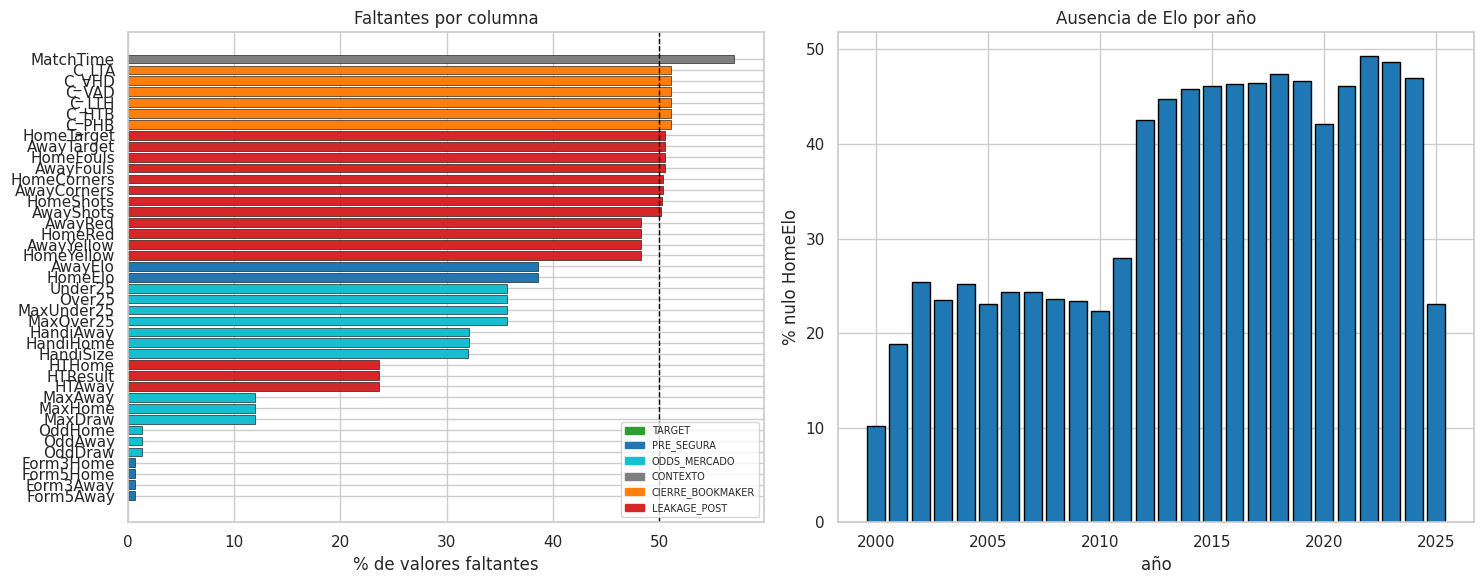

anio
2000    10.1
2001    18.9
2002    25.4
2003    23.5
2004    25.2
2005    23.1
2006    24.4
2007    24.4
2008    23.6
2009    23.4
2010    22.4
2011    27.9
2012    42.5
2013    44.8
2014    45.8
2015    46.1
2016    46.3
2017    46.5
2018    47.4
2019    46.7
2020    42.2
2021    46.1
2022    49.3
2023    48.6
2024    46.9
2025    23.1


In [6]:
# Nulos de Elo por año: ¿es un artefacto temporal?
by_year = matches.assign(anio=matches["MatchDate"].dt.year)
elo_year = by_year.groupby("anio")["HomeElo"].apply(lambda s: 100*s.isna().mean())

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
# (izq) barras de % nulos por columna, coloreadas por grupo
GROUP_COLORS = {"TARGET":"#2ca02c","PRE_SEGURA":"#1f77b4","ODDS_MERCADO":"#17becf",
                "CONTEXTO":"#7f7f7f","CIERRE_BOOKMAKER":"#ff7f0e","LEAKAGE_POST":"#d62728"}
pdf = tab_null[tab_null.pct_nulos > 0].iloc[::-1]
axes[0].barh(pdf.index, pdf.pct_nulos, color=[GROUP_COLORS[g] for g in pdf.grupo],
             edgecolor="black", linewidth=0.4)
axes[0].axvline(50, color="black", ls="--", lw=1)
axes[0].set_xlabel("% de valores faltantes"); axes[0].set_title("Faltantes por columna")
axes[0].legend([plt.Rectangle((0,0),1,1,color=c) for c in GROUP_COLORS.values()],
               GROUP_COLORS.keys(), fontsize=7, loc="lower right")
# (der) % nulos de Elo por año
axes[1].bar(elo_year.index, elo_year.values, color="#1f77b4", edgecolor="black")
axes[1].set_xlabel("año"); axes[1].set_ylabel("% nulo HomeElo")
axes[1].set_title("Ausencia de Elo por año")
plt.tight_layout()
plt.savefig(FIG_DIR / "missingness_bar.png", dpi=150)
plt.show()
print(elo_year.round(1).to_string())

### Interpretación

Las estadísticas de juego rondan el 50% de ausencia porque solo se registran en las ligas y temporadas con cobertura detallada; como además son fuga, su descarte queda doblemente justificado. Las seis columnas `C_*` (cierre de casa de apuestas) superan el 51% y aportan poco valor documentado. El rating Elo tiene cerca de 38.6% de nulos, pero el patrón desmiente la hipótesis de que solo exista desde 2006: la ausencia ronda 10–25% en 2000–2011 y **asciende a 42–49% en 2012–2024**, cuando el dataset incorpora divisiones menores sin cobertura Elo. En consecuencia, filtrar por año no resolvería el faltante; el problema es estructural por liga, y se retomará en la sección de decisiones.

## 3. Balance de clases del objetivo

### Fundamentación

En clasificación multiclase, el desbalance sesga el aprendizaje hacia la clase dominante y vuelve engañosa la exactitud global. Se cuantifica con el índice de desbalance $\text{IR} = n_{\max}/n_{\min}$ y se establecen dos líneas base triviales que todo modelo debe superar: predecir siempre la clase mayoritaria y predecir según la distribución a priori.

Distribución de FTResult:
  Local (H)    102,873  44.62%
  Empate (D)    61,121  26.51%
  Visita (A)    66,560  28.87%

IR = 102,873/61,121 = 1.683  (desbalance moderado)
Baseline mayoritario (accuracy): 0.4462
Baseline aleatorio estratificado: 0.3527


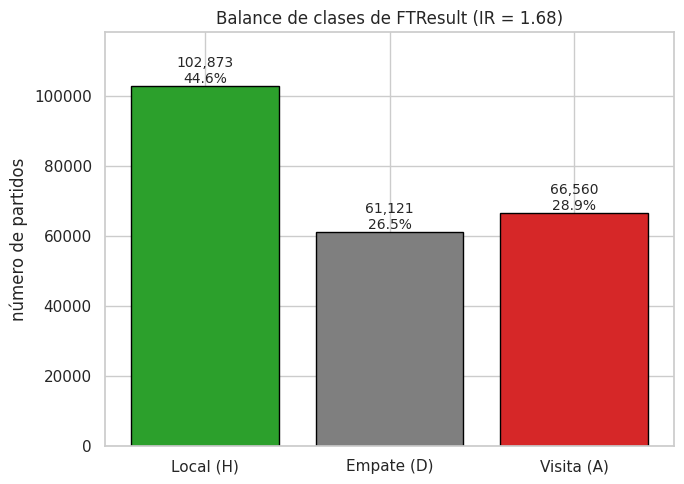

In [7]:
y = matches[TARGET].dropna()
counts = y.value_counts().reindex(TARGET_ORDER)
prop = counts / counts.sum()
IR = counts.max() / counts.min()
print("Distribución de FTResult:")
for c in TARGET_ORDER:
    print(f"  {CLASS_LABEL[c]:<11} {counts[c]:>8,}  {prop[c]*100:5.2f}%")
print(f"\nIR = {counts.max():,}/{counts.min():,} = {IR:.3f}  (desbalance moderado)")
print(f"Baseline mayoritario (accuracy): {prop.max():.4f}")
print(f"Baseline aleatorio estratificado: {(prop**2).sum():.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
b = ax.bar([CLASS_LABEL[c] for c in TARGET_ORDER], [counts[c] for c in TARGET_ORDER],
           color=[CLASS_COLOR[c] for c in TARGET_ORDER], edgecolor="black")
for c, bar in zip(TARGET_ORDER, b):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(),
            f"{counts[c]:,}\n{prop[c]*100:.1f}%", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("número de partidos"); ax.set_ylim(0, counts.max()*1.15)
ax.set_title(f"Balance de clases de FTResult (IR = {IR:.2f})")
plt.tight_layout(); plt.savefig(FIG_DIR / "class_balance.png", dpi=150); plt.show()

### Interpretación

La victoria local domina con 44.6%, seguida de la visita (28.9%) y el empate (26.5%). El índice $\text{IR} = 1.68$ describe un desbalance moderado, no severo: no se requiere sobre-muestreo agresivo, y basta con ponderar las clases (`class_weight='balanced'`) y reportar F1 por clase. El empate es la clase minoritaria y, como se verá, la más difícil de aislar. Cualquier modelo debe superar una exactitud de 0.446 para aportar valor por encima de la regla trivial de apostar siempre al local.

## 4. Estadística descriptiva

### Fundamentación

Se reportan medidas de tendencia central, dispersión, percentiles y forma (asimetría y curtosis) para las variables pre-partido, sus derivadas y las cuotas. La asimetría y la curtosis anticipan la necesidad de escalado o de transformaciones, y los percentiles extremos delatan valores atípicos o centinela.

In [8]:
def describir(cols):
    d = matches[cols].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).T
    d["skew"] = matches[cols].skew()
    d["kurtosis"] = matches[cols].kurtosis()
    return d.round(3)

print("[A] Variables pre-partido seguras")
print(describir(SAFE_PRE_NUMERIC).to_string())
print("\n[B] Variables derivadas")
print(describir(["elo_diff","form3_diff","form5_diff"]).to_string())
print("\n[C] Cuotas principales")
print(describir(["OddHome","OddDraw","OddAway"]).to_string())

[A] Variables pre-partido seguras


              count      mean      std      min        1%        5%      25%       50%       75%      95%       99%      max   skew  kurtosis
HomeElo    141597.0  1533.119  153.280  1103.13  1216.129  1305.400  1424.87  1515.450  1634.240  1804.96  1938.965  2107.48  0.427     0.120
AwayElo    141528.0  1533.166  153.295  1103.13  1216.480  1305.284  1424.93  1515.475  1634.222  1805.30  1938.377  2107.48  0.428     0.120
Form3Home  229057.0     3.985    2.377     0.00     0.000     0.000     2.00     4.000     6.000     9.00     9.000     9.00  0.226    -0.626
Form5Home  229057.0     6.722    3.257     0.00     0.000     1.000     4.00     7.000     9.000    12.00    15.000    15.00  0.200    -0.398
Form3Away  229057.0     4.203    2.393     0.00     0.000     0.000     3.00     4.000     6.000     9.00     9.000     9.00  0.149    -0.670
Form5Away  229057.0     6.928    3.270     0.00     0.000     2.000     4.00     7.000     9.000    13.00    15.000    15.00  0.163    -0.420

[B] V

### Interpretación

El Elo se concentra alrededor de 1533 con dispersión moderada (desviación 153) y ligera asimetría positiva. La variable `elo_diff` tiene media prácticamente nula (0.01) y mediana también cercana a cero: el Elo es simétrico entre local y visita, de modo que la ventaja de localía no proviene de un sesgo de emparejamiento sino del hecho de jugar en casa. Las cuotas confirman el sesgo desde la perspectiva del mercado, con `OddHome` (2.46) claramente inferior a `OddDraw` (3.61) y `OddAway` (4.02). La forma reciente toma valores enteros acotados (0–9 para la ventana de tres partidos y 0–15 para la de cinco), coherentes con puntos acumulados y disponibles antes del encuentro.

## 5. Distribuciones de las variables densas

### Fundamentación

La rúbrica exige visualizar las distribuciones de las variables continuas. Se examinan los goles (contexto, no entrada), el Elo, la diferencia de Elo y la forma reciente, atendiendo a su forma funcional (asimetría, discreción, simetría).

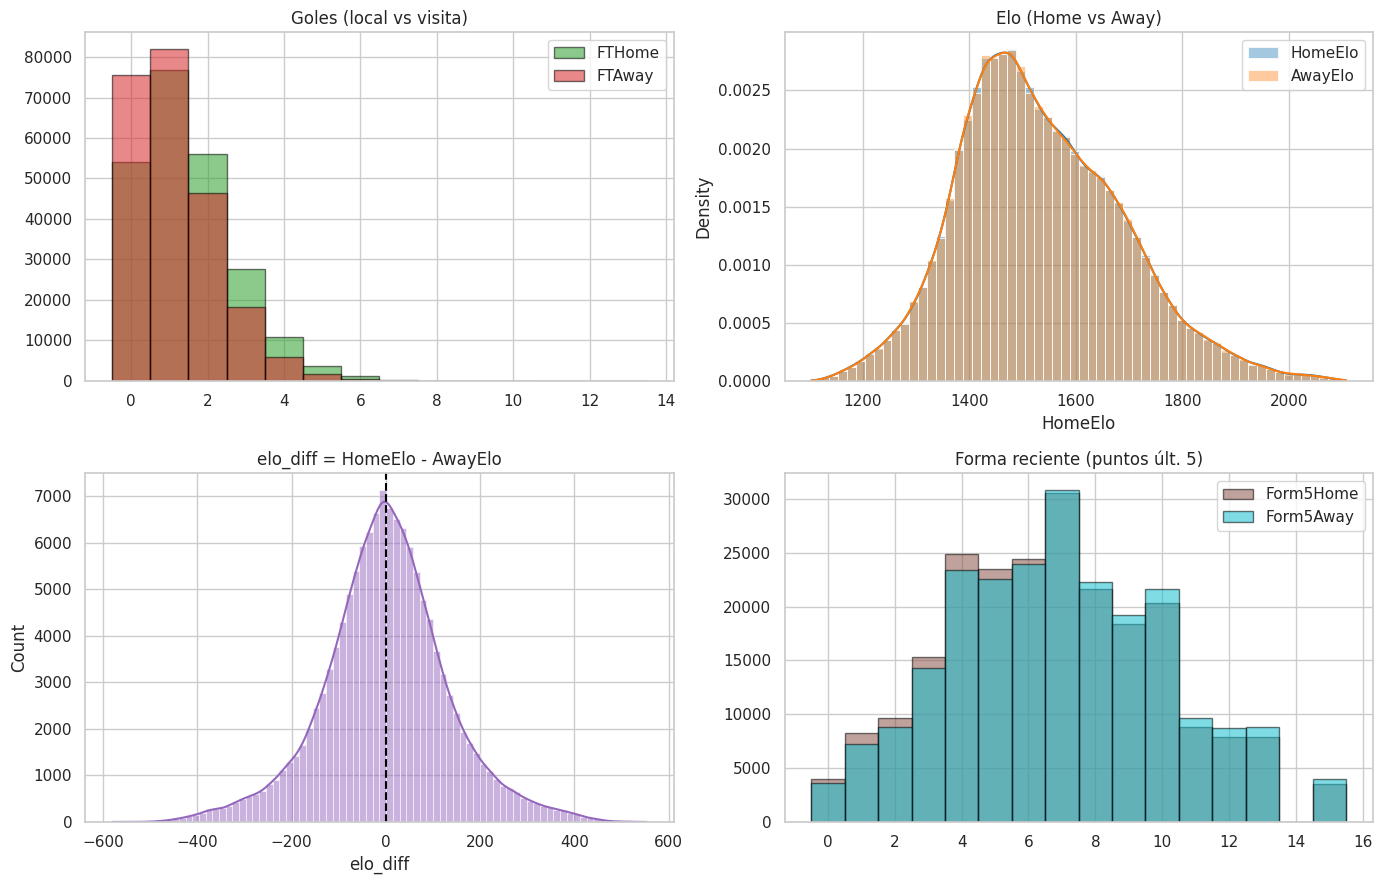

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
# goles
for col, cl in zip(["FTHome","FTAway"], ["#2ca02c","#d62728"]):
    v = matches[col].dropna()
    axes[0,0].hist(v, bins=np.arange(-.5, v.max()+1.5, 1), alpha=0.55,
                   color=cl, edgecolor="black", label=col)
axes[0,0].set_title("Goles (local vs visita)"); axes[0,0].legend()
# Elo
for col, cl in zip(["HomeElo","AwayElo"], ["#1f77b4","#ff7f0e"]):
    sns.histplot(matches[col].dropna(), bins=60, kde=True, stat="density",
                 color=cl, alpha=0.4, label=col, ax=axes[0,1])
axes[0,1].set_title("Elo (Home vs Away)"); axes[0,1].legend()
# elo_diff
sns.histplot(matches["elo_diff"].dropna(), bins=80, kde=True, color="#9467bd", ax=axes[1,0])
axes[1,0].axvline(0, color="black", ls="--"); axes[1,0].set_title("elo_diff = HomeElo - AwayElo")
# forma
for col, cl in zip(["Form5Home","Form5Away"], ["#8c564b","#17becf"]):
    v = matches[col].dropna()
    axes[1,1].hist(v, bins=np.arange(-.5, v.max()+1.5, 1), alpha=0.55,
                   color=cl, edgecolor="black", label=col)
axes[1,1].set_title("Forma reciente (puntos últ. 5)"); axes[1,1].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "dist_goals.png", dpi=150)
plt.savefig(FIG_DIR / "dist_elo.png", dpi=150)
plt.show()

### Interpretación

Los goles muestran una asimetría positiva típica de un proceso de conteo (similar a una Poisson), con moda en un gol para el local y una media superior a la del visitante, lo que reproduce la ventaja de localía en el marcador. El Elo se aproxima a una normal ligeramente sesgada. La diferencia de Elo es notablemente simétrica y centrada en cero, imagen directa del equilibrio en el emparejamiento. La forma reciente es discreta y con poca asimetría, sin valores imposibles.

## 6. Correlación lineal y no lineal

### Fundamentación

Se calculan la correlación de Pearson, que mide asociación lineal, y la de Spearman, que capta relaciones monótonas y resiste mejor a los valores atípicos. La comparación entre ambas revela no linealidades. Se identifican pares fuertemente asociados (posible redundancia) y se estima la relación de cada atributo con el resultado mediante una correlación punto-biserial frente al indicador de victoria local.

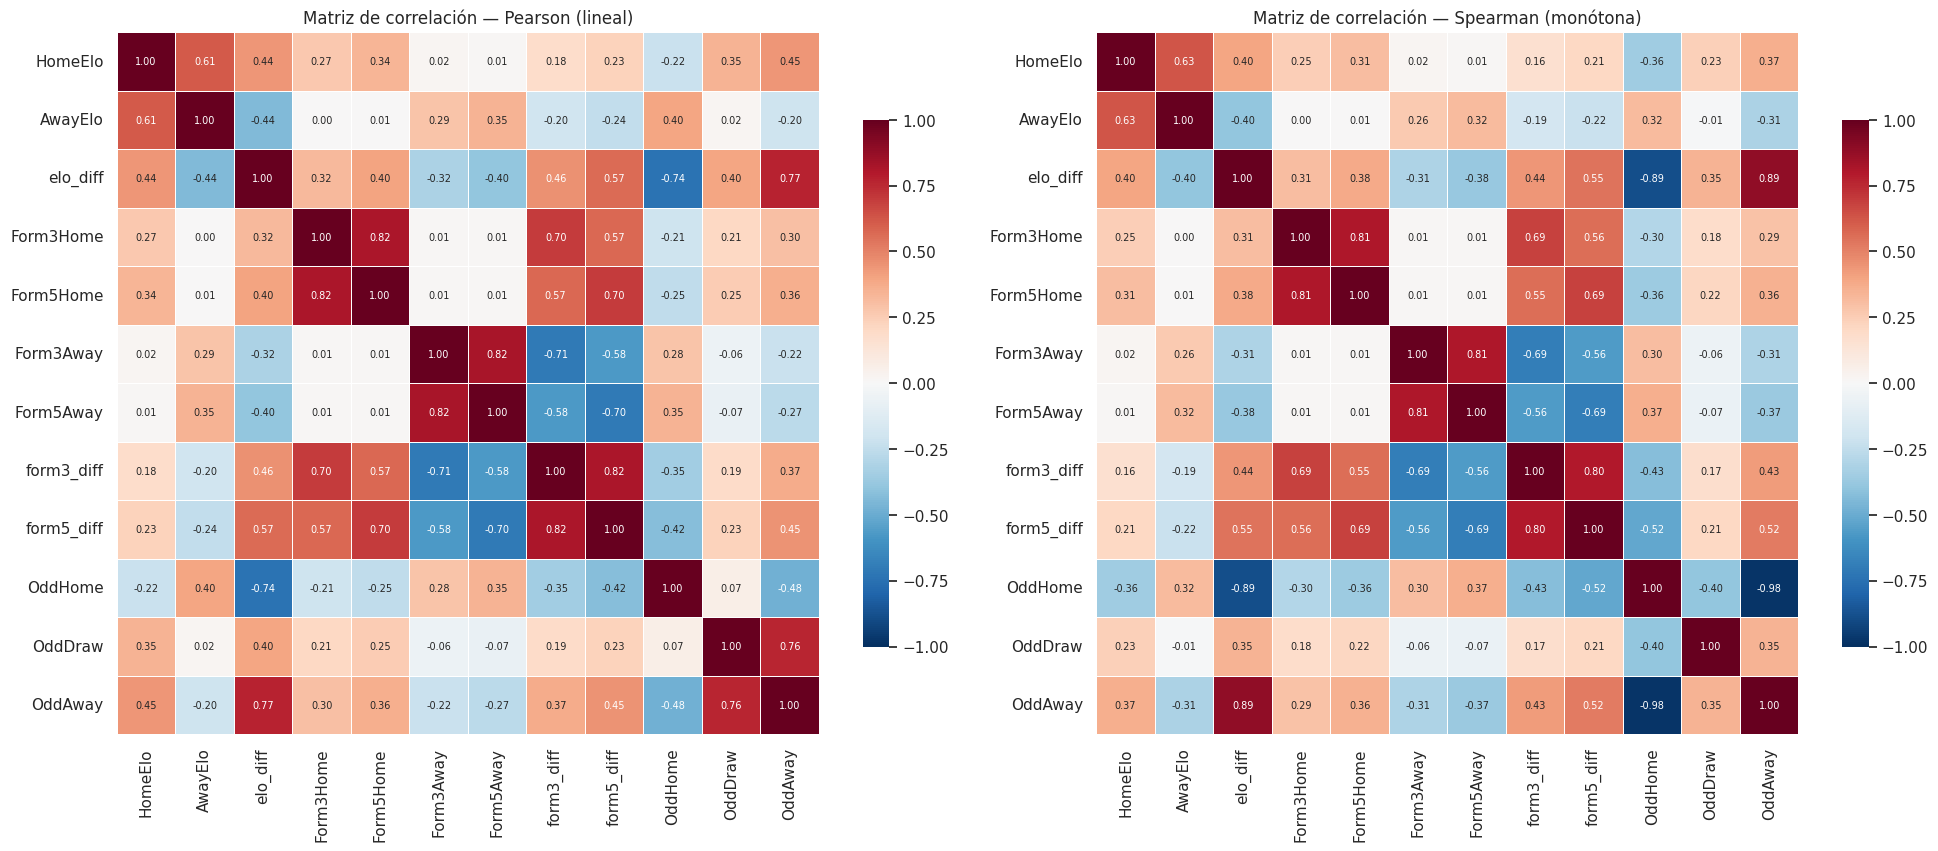

Pares con |Pearson| > 0.7 (asociación fuerte):
  elo_diff    ~ OddHome     r = -0.738
  elo_diff    ~ OddAway     r = +0.772
  Form3Home   ~ Form5Home   r = +0.820
  Form3Home   ~ form3_diff  r = +0.701
  Form5Home   ~ form5_diff  r = +0.701
  Form3Away   ~ Form5Away   r = +0.822
  Form3Away   ~ form3_diff  r = -0.706
  Form5Away   ~ form5_diff  r = -0.704
  form3_diff  ~ form5_diff  r = +0.817
  OddDraw     ~ OddAway     r = +0.760

Correlación de cada feature con 'gana el local' (H=1):
  elo_diff    r = +0.300
  OddAway     r = +0.264
  OddHome     r = -0.235
  form5_diff  r = +0.165
  OddDraw     r = +0.147
  HomeElo     r = +0.140
  form3_diff  r = +0.136
  Form5Home   r = +0.118
  Form5Away   r = -0.114
  AwayElo     r = -0.112
  Form3Home   r = +0.097
  Form3Away   r = -0.094


In [10]:
FEAT = ["HomeElo","AwayElo","elo_diff","Form3Home","Form5Home","Form3Away",
        "Form5Away","form3_diff","form5_diff","OddHome","OddDraw","OddAway"]
pear = matches[FEAT].corr("pearson")
spear = matches[FEAT].corr("spearman")

fig, axes = plt.subplots(1, 2, figsize=(20, 8.5))
for ax, mat, t in zip(axes, [pear, spear], ["Pearson (lineal)", "Spearman (monótona)"]):
    sns.heatmap(mat, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, center=0,
                square=True, linewidths=.5, annot_kws={"size":7}, cbar_kws={"shrink":.7}, ax=ax)
    ax.set_title(f"Matriz de correlación — {t}")
plt.tight_layout()
plt.savefig(FIG_DIR / "correlation_matrix.png", dpi=150)
plt.savefig(FIG_DIR / "correlation_spearman.png", dpi=150)
plt.show()

print("Pares con |Pearson| > 0.7 (asociación fuerte):")
cols = pear.columns
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        r = pear.iloc[i, j]
        if abs(r) > 0.7:
            print(f"  {cols[i]:<11} ~ {cols[j]:<11} r = {r:+.3f}")

y_home = (matches["FTResult"] == "H").astype(float)
print("\nCorrelación de cada feature con 'gana el local' (H=1):")
rs = []
for f in FEAT:
    s = matches[f]; msk = s.notna()
    rs.append((f, np.corrcoef(s[msk], y_home[msk])[0,1]))
for f, r in sorted(rs, key=lambda t: -abs(t[1])):
    print(f"  {f:<11} r = {r:+.3f}")

### Interpretación

La señal pre-partido más informativa es `elo_diff`, con la mayor correlación con la victoria local, seguida por las cuotas. La comparación Pearson–Spearman expone un punto delicado: en la escala monótona, `elo_diff` se asocia con las cuotas en torno a 0.89 y `OddHome` con `OddAway` en −0.98. Las cuotas de mercado codifican, en la práctica, casi la misma información que el Elo; funcionan como una fuga del conocimiento del apostador experto. Esto obliga a evaluar el modelo en dos versiones, con y sin cuotas, para medir su aporte real. Las asociaciones fuertes entre `Form3` y `Form5` de un mismo equipo, y entre cada diferencia y sus componentes, anticipan la revisión de multicolinealidad de la sección siguiente.

## 7. Multicolinealidad (VIF)

### Fundamentación

El Factor de Inflación de la Varianza mide cuánto se amplifica la varianza del coeficiente de una variable por su correlación con las demás. Se obtiene como el elemento diagonal de la inversa de la matriz de correlación, $\text{VIF}_i = (\mathbf{R}^{-1})_{ii}$. Se interpreta como grave por encima de 10 y moderado entre 5 y 10. Las diferencias derivadas se excluyen de este cálculo porque son combinación lineal exacta de sus componentes y volverían singular a $\mathbf{R}$.

VIF por feature:
  OddAway       8.85  (moderada)
  HomeElo       6.61  (moderada)
  AwayElo       6.33  (moderada)
  OddDraw       6.06  (moderada)
  OddHome       4.39  (baja)
  Form5Away     3.43  (baja)
  Form5Home     3.41  (baja)
  Form3Away     3.11  (baja)
  Form3Home     3.09  (baja)

VIF medio = 5.03   VIF máx = 8.85 (OddAway)


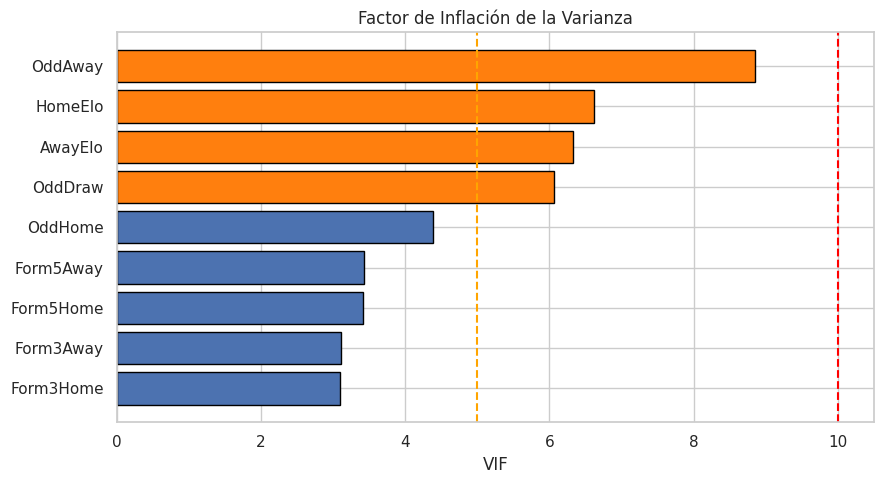

In [11]:
MODEL_FEAT = ["HomeElo","AwayElo","Form3Home","Form5Home","Form3Away","Form5Away",
              "OddHome","OddDraw","OddAway"]
Xc = matches[MODEL_FEAT].dropna()
R = Xc.corr("pearson")
vif = pd.Series(np.diag(np.linalg.inv(R.values)), index=R.columns).sort_values(ascending=False)
print("VIF por feature:")
for f, v in vif.items():
    tag = "GRAVE" if v > 10 else "moderada" if v > 5 else "baja"
    print(f"  {f:<11} {v:6.2f}  ({tag})")
print(f"\nVIF medio = {vif.mean():.2f}   VIF máx = {vif.max():.2f} ({vif.idxmax()})")

fig, ax = plt.subplots(figsize=(9, 5))
col = ["#d62728" if v>10 else "#ff7f0e" if v>5 else "#4c72b0" for v in vif.values[::-1]]
ax.barh(vif.index[::-1], vif.values[::-1], color=col, edgecolor="black")
ax.axvline(5, color="orange", ls="--"); ax.axvline(10, color="red", ls="--")
ax.set_xlabel("VIF"); ax.set_title("Factor de Inflación de la Varianza")
plt.tight_layout(); plt.savefig(FIG_DIR / "vif_barplot.png", dpi=150); plt.show()

### Interpretación

Ninguna variable presenta multicolinealidad grave: el VIF máximo es 8.85 (`OddAway`) y solo cuatro atributos caen en la franja moderada (las cuotas y ambos Elo). El promedio ronda 5. Para los modelos lineales conviene recordar dos reglas prácticas: usar las diferencias o los componentes, nunca ambos, porque `elo_diff` y `form_diff` son combinaciones exactas que producen singularidad; y, si la colinealidad entre `Form3` y `Form5` incomoda, conservar la ventana de cinco por contener más información. Los modelos de árboles (Random Forest, XGBoost, LightGBM) son inmunes a la multicolinealidad, de modo que allí esta preocupación no aplica.

## 8. Valores atípicos univariados y multivariados

### Fundamentación

Se combinan dos criterios. El rango intercuartílico marca como atípico todo valor fuera de $[Q_1 - 1.5\,\text{IQR},\, Q_3 + 1.5\,\text{IQR}]$, columna por columna. La distancia de Mahalanobis, $D_M^2(\mathbf{x}) = (\mathbf{x}-\boldsymbol{\mu})^\top \boldsymbol{\Sigma}^{-1} (\mathbf{x}-\boldsymbol{\mu})$, evalúa la rareza en el espacio conjunto y detecta anomalías por combinación que el análisis por columna no percibe; bajo normalidad multivariante sigue una $\chi^2$ con $D$ grados de libertad.

In [12]:
# --- Univariado (IQR) sobre Elo, elo_diff y cuotas ---
def iqr_out(s):
    s = s.dropna(); q1, q3 = s.quantile(.25), s.quantile(.75); iqr = q3-q1
    return int(((s < q1-1.5*iqr) | (s > q3+1.5*iqr)).sum()), len(s)
print("Outliers univariados (IQR):")
for c in ["HomeElo","AwayElo","elo_diff","Form5Home","OddHome","OddDraw","OddAway"]:
    o, n = iqr_out(matches[c]); print(f"  {c:<11} {o:>7,} / {n:,} ({100*o/n:.2f}%)")

# valores imposibles / centinela en cuotas
print("\nValores centinela / imposibles:")
print(f"  OddHome == 0: {int((matches['OddHome']==0).sum())}   "
      f"HandiSize == -99.9: {int((matches['HandiSize']==-99.90).sum())}   "
      f"MaxAway máx: {matches['MaxAway'].max():.0f}")

Outliers univariados (IQR):
  HomeElo       1,227 / 141,597 (0.87%)
  AwayElo       1,221 / 141,528 (0.86%)
  elo_diff      4,982 / 132,413 (3.76%)
  Form5Home         0 / 229,057 (0.00%)
  OddHome      15,514 / 227,527 (6.82%)
  OddDraw      20,415 / 227,527 (8.97%)
  OddAway      17,280 / 227,527 (7.59%)

Valores centinela / imposibles:
  OddHome == 0: 7   HandiSize == -99.9: 2   MaxAway máx: 301


n = 132,005   umbral chi2(0.999, df=6) = 22.46
Outliers multivariados: 78 (0.06%)
Atípico multivariado pero NO univariado (anomalía por combinación): 28

Variable que dispara el outlier (|z| máx):
AwayElo      30
HomeElo      29
Form5Home    12
Form5Away     5
Form3Home     2

Arquetipos:
Elo extremo (super-club / colista)                   53
Local débil en racha (Elo bajo + forma perfecta)      7
Combinación fuerza-forma atípica                      6
Visita débil en racha (Elo bajo + forma perfecta)     5
Visita fuerte en crisis (Elo alto + forma nula)       4
Local fuerte en crisis (Elo alto + forma nula)        3

Top-6 outliers (equipos reales):
  D_M2= 35.1 | Utrecht (Elo 1462, F5 15) vs PSV Eindhoven (Elo 1742, F5 0) | Visita fuerte en crisis (Elo alto + forma nula)
  D_M2= 30.8 | Real Madrid (Elo 1954, F5 1) vs Valladolid (Elo 1664, F5 13) | Local fuerte en crisis (Elo alto + forma nula)
  D_M2= 30.3 | Braunschweig (Elo 1576, F5 7) vs Bayern Munich (Elo 2062, F5 7) | Elo extre

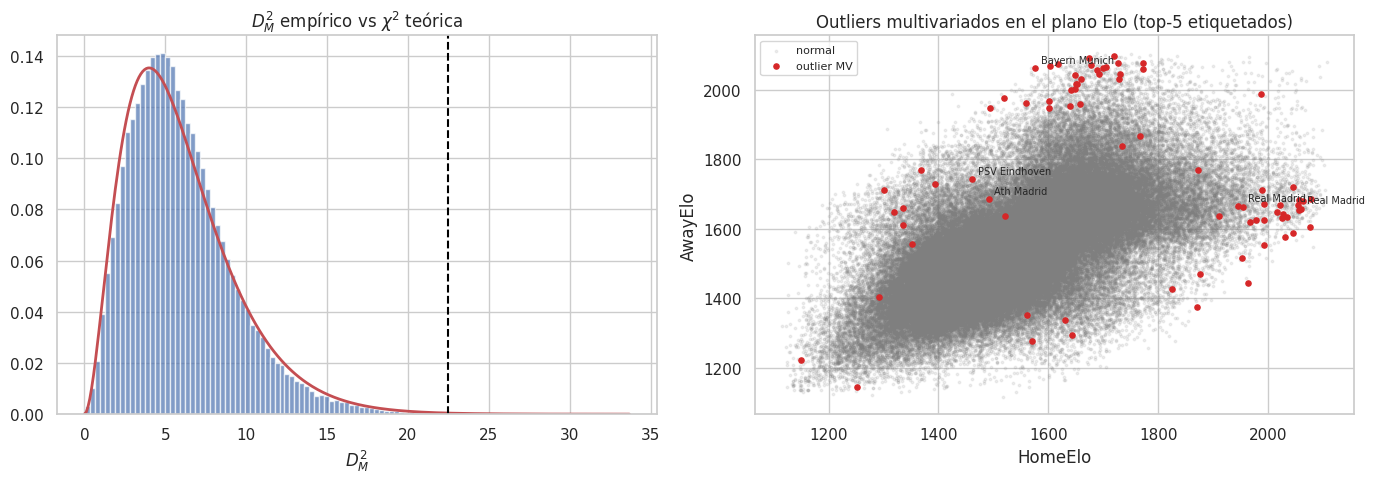

In [13]:
# --- Multivariado (Mahalanobis) sobre features pre-partido ---
FM = ["HomeElo","AwayElo","Form3Home","Form5Home","Form3Away","Form5Away"]
sub = matches[FM].dropna(); Xv = sub.values
mu = Xv.mean(0); sd = Xv.std(0); cov = np.cov(Xv, rowvar=False)
inv = np.linalg.inv(cov + 1e-6*np.eye(len(FM)))
dm2 = np.einsum("ij,jk,ik->i", Xv-mu, inv, Xv-mu)
Zc = (Xv - mu) / sd                       # z-scores por variable
thr = chi2.ppf(0.999, df=len(FM))
mv = dm2 > thr
info = matches.loc[sub.index, ["MatchDate","Division","HomeTeam","AwayTeam"]].reset_index(drop=True)
print(f"n = {len(sub):,}   umbral chi2(0.999, df={len(FM)}) = {thr:.2f}")
print(f"Outliers multivariados: {int(mv.sum()):,} ({100*mv.mean():.2f}%)")

uni = np.zeros(len(sub), bool)
for j in range(len(FM)):
    s = Xv[:,j]; q1,q3 = np.percentile(s,[25,75]); iqr=q3-q1
    uni |= (s < q1-1.5*iqr) | (s > q3+1.5*iqr)
print(f"Atípico multivariado pero NO univariado (anomalía por combinación): "
      f"{int((mv & ~uni).sum())}")

# Que variable dispara cada outlier + arquetipo futbolero
def arquetipo(z):   # z = [HomeElo, AwayElo, F3H, F5H, F3A, F5A]
    he, ae, f5h, f5a = z[0], z[1], z[3], z[5]
    if he > 1 and f5h < -1.2: return "Local fuerte en crisis (Elo alto + forma nula)"
    if ae > 1 and f5a < -1.2: return "Visita fuerte en crisis (Elo alto + forma nula)"
    if he < -1 and f5h > 1.2: return "Local débil en racha (Elo bajo + forma perfecta)"
    if ae < -1 and f5a > 1.2: return "Visita débil en racha (Elo bajo + forma perfecta)"
    if max(abs(he), abs(ae)) > 2.5: return "Elo extremo (super-club / colista)"
    return "Combinación fuerza-forma atípica"

oi = np.where(mv)[0]
dom = pd.Series([FM[int(np.argmax(np.abs(Zc[i])))] for i in oi]).value_counts()
arq = pd.Series([arquetipo(Zc[i]) for i in oi]).value_counts()
print("\nVariable que dispara el outlier (|z| máx):")
print(dom.to_string())
print("\nArquetipos:")
print(arq.to_string())
print("\nTop-6 outliers (equipos reales):")
for i in oi[np.argsort(dm2[oi])[::-1]][:6]:
    r = info.iloc[i]
    print(f"  D_M2={dm2[i]:5.1f} | {r['HomeTeam']} (Elo {Xv[i,0]:.0f}, F5 {Xv[i,3]:.0f}) vs "
          f"{r['AwayTeam']} (Elo {Xv[i,1]:.0f}, F5 {Xv[i,5]:.0f}) | {arquetipo(Zc[i])}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(dm2[dm2 < thr*1.5], bins=100, density=True, color="#4c72b0", alpha=.7)
xs = np.linspace(0, thr*1.5, 300)
axes[0].plot(xs, chi2.pdf(xs, len(FM)), "r-", lw=2)
axes[0].axvline(thr, color="black", ls="--")
axes[0].set_title("$D_M^2$ empírico vs $\\chi^2$ teórica"); axes[0].set_xlabel("$D_M^2$")
axes[1].scatter(Xv[~mv,0], Xv[~mv,1], s=3, alpha=.12, color="#7f7f7f", label="normal")
axes[1].scatter(Xv[mv,0], Xv[mv,1], s=14, color="#d62728", label="outlier MV")
for i in oi[np.argsort(dm2[oi])[::-1]][:5]:
    eq = info.iloc[i]["HomeTeam"] if abs(Zc[i,0]) >= abs(Zc[i,1]) else info.iloc[i]["AwayTeam"]
    axes[1].annotate(eq, (Xv[i,0], Xv[i,1]), fontsize=7, xytext=(4,4), textcoords="offset points")
axes[1].set_xlabel("HomeElo"); axes[1].set_ylabel("AwayElo"); axes[1].legend(fontsize=8)
axes[1].set_title("Outliers multivariados en el plano Elo (top-5 etiquetados)")
plt.tight_layout(); plt.savefig(FIG_DIR / "mahalanobis_outliers.png", dpi=150)
plt.savefig(FIG_DIR / "boxplots_outliers.png", dpi=150); plt.show()

### Interpretación

El Elo y la forma no contienen valores imposibles: sus atípicos por IQR son extremos legítimos (equipos muy fuertes o muy débiles). Las cuotas, en cambio, presentan centinelas y errores de captura, como cuotas iguales a cero, el valor $-99.9$ en `HandiSize` y máximos absurdos superiores a 300, que deberán limpiarse o acotarse en el preprocesamiento.

**Qué outliers detecta Mahalanobis y por qué.** De los 78 casos atípicos (0.06%), unos dos tercios son *super-clubes* cuyo rating Elo se ubica en el techo de su liga (Bayern Múnich en 1.6M ~2062, Real Madrid ~2060, PSG, Ajax), muy por encima de la media de 1533; el propio rating los aleja del resto. El grupo más interesante son las **contradicciones entre fuerza y forma**, que el análisis por columna no percibe: un grande en mala racha (Elo alto con forma reciente nula, como el Real Madrid de noviembre de 2018 con `Form5=1`) o un modesto en racha perfecta (Elo bajo con `Form5=15`, como Jaén o Amiens). En estos casos ningún campo es extremo por sí solo, pero la combinación rompe la relación esperada, ya que Elo y forma están correlacionados de forma positiva ($r \approx 0.31$): un equipo fuerte "debería" traer buena forma. Precisamente por combinar variables mediante la inversa de la covarianza, la distancia de Mahalanobis los identifica donde el criterio IQR falla. La cola algo más pesada que la $\chi^2$ teórica indica una leve desviación de la normalidad multivariante.

## 9. Análisis bivariado: variables frente al resultado

### Fundamentación

Para verificar que existe señal predictiva antes del partido se compara la distribución de cada variable pre-partido condicionada a cada clase del resultado. Si las medianas se ordenan de forma coherente con el resultado, la variable aporta capacidad discriminante.

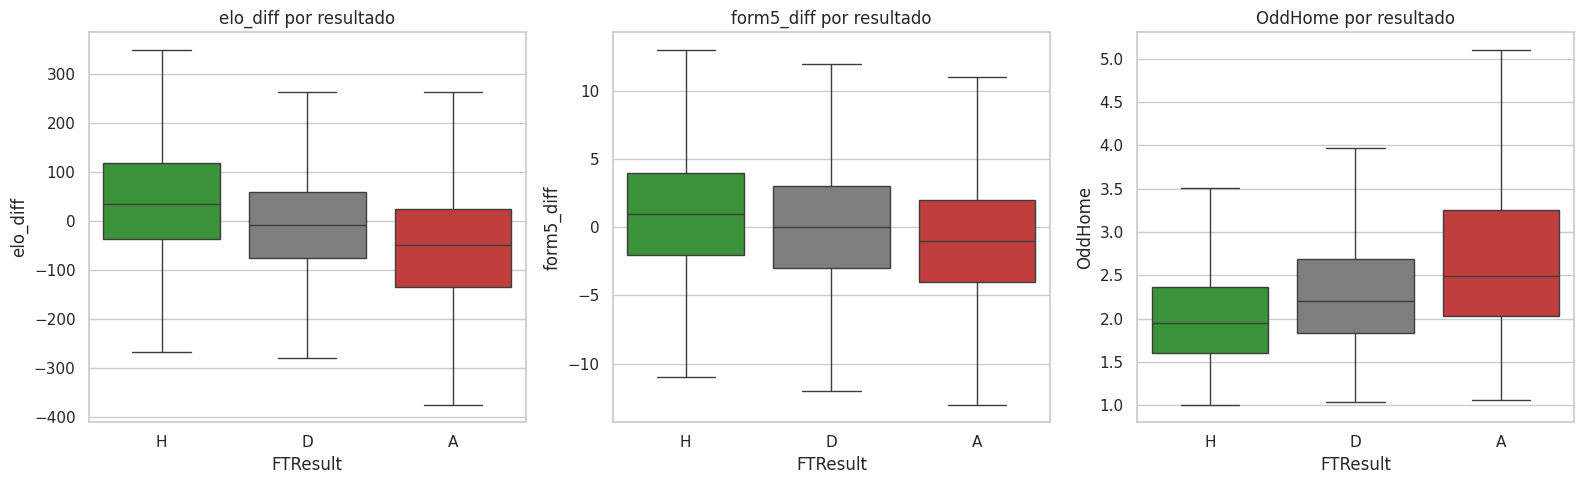

Media por clase:
          HomeElo  AwayElo  elo_diff  Form5Home  Form5Away  form5_diff  OddHome  OddDraw  OddAway
FTResult                                                                                         
H         1556.70  1514.09     44.00       7.15       6.51        0.64     2.10     3.75     4.80
D         1522.64  1532.77     -9.87       6.60       7.01       -0.41     2.44     3.47     3.71
A         1504.93  1563.68    -61.33       6.17       7.50       -1.32     3.03     3.52     3.10


In [14]:
mb = matches[matches["FTResult"].notna()]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, f in zip(axes, ["elo_diff","form5_diff","OddHome"]):
    sns.boxplot(data=mb, x="FTResult", y=f, order=TARGET_ORDER, hue="FTResult",
                palette=CLASS_COLOR, legend=False, showfliers=False, ax=ax)
    ax.set_title(f"{f} por resultado")
plt.tight_layout(); plt.savefig(FIG_DIR / "elo_by_result.png", dpi=150)
plt.savefig(FIG_DIR / "form_by_result.png", dpi=150); plt.show()

print("Media por clase:")
print(mb.groupby("FTResult")[["HomeElo","AwayElo","elo_diff","Form5Home",
      "Form5Away","form5_diff","OddHome","OddDraw","OddAway"]].mean()
      .reindex(TARGET_ORDER).round(2).to_string())

### Interpretación

Las diferencias pre-partido se ordenan de forma monótona con el resultado. La `elo_diff` media pasa de $+44$ en las victorias locales a $-10$ en los empates y $-61$ en las derrotas; la diferencia de forma sigue el mismo patrón. Cuando el local es más fuerte tiende a ganar, y cuando lo es el visitante tiende a ganar la visita. El empate ocupa siempre la posición intermedia, con diferencias cercanas a cero, lo que anticipa su dificultad: carece de una región propia en el espacio de atributos. Existe, por tanto, señal genuina antes del partido, condición necesaria para que el modelado tenga sentido.

## 10. Anatomía del empate

### Fundamentación

Dado que el empate es la clase minoritaria e intermedia, se estudia su tasa condicionada a la paridad de fuerzas, medida por $|\text{elo\_diff}|$ y por la diferencia de forma. El objetivo es determinar si existe alguna región del espacio donde el empate llegue a ser la clase mayoritaria.

Resultado según |elo_diff| (paridad de fuerzas):
FTResult     H     D     A      n
abin                             
0-25      44.0  29.8  26.2  23953
25-50     44.4  29.6  25.9  21950
50-100    44.6  28.5  26.9  34995
100-200   45.7  25.4  28.9  34241
>200      47.6  18.3  34.1  17200

Tasa de empate máxima en cualquier bin: 29.8%


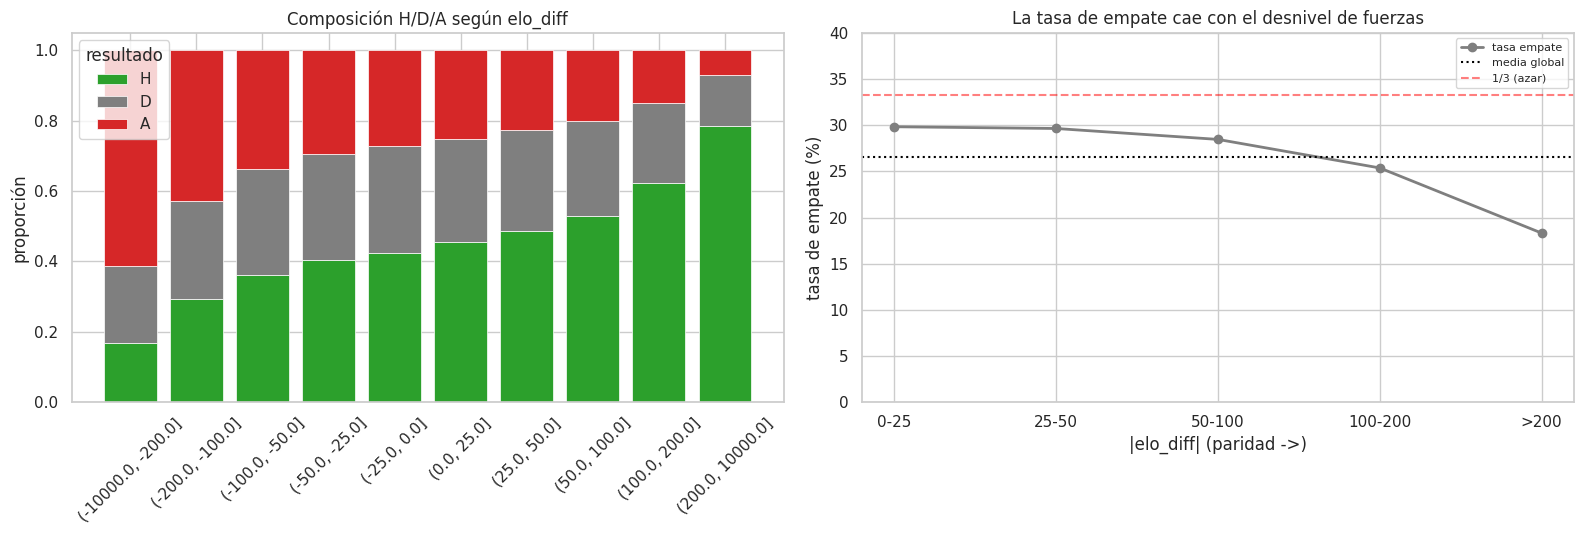

In [15]:
md_ = mb.dropna(subset=["elo_diff"]).copy()
md_["abin"] = pd.cut(md_["elo_diff"].abs(), [0,25,50,100,200,1e4],
                     labels=["0-25","25-50","50-100","100-200",">200"])
t1 = md_.groupby("abin", observed=True)["FTResult"].value_counts(normalize=True)\
        .unstack().reindex(columns=TARGET_ORDER)
t1["n"] = md_.groupby("abin", observed=True).size()
print("Resultado según |elo_diff| (paridad de fuerzas):")
print((t1[TARGET_ORDER]*100).round(1).assign(n=t1["n"]).to_string())
print(f"\nTasa de empate máxima en cualquier bin: {t1['D'].max()*100:.1f}%")

md_["sbin"] = pd.cut(md_["elo_diff"], [-1e4,-200,-100,-50,-25,0,25,50,100,200,1e4])
t2 = md_.groupby("sbin", observed=True)["FTResult"].value_counts(normalize=True)\
        .unstack().reindex(columns=TARGET_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
bottom = np.zeros(len(t2)); xl = [str(i) for i in t2.index]
for cls in TARGET_ORDER:
    axes[0].bar(xl, t2[cls].values, bottom=bottom, color=CLASS_COLOR[cls], label=cls,
                edgecolor="white", linewidth=.5); bottom += t2[cls].values
axes[0].set_title("Composición H/D/A según elo_diff"); axes[0].legend(title="resultado")
axes[0].tick_params(axis="x", rotation=45); axes[0].set_ylabel("proporción")
axes[1].plot(["0-25","25-50","50-100","100-200",">200"], t1["D"].values*100,
             "o-", color="#7f7f7f", lw=2, label="tasa empate")
axes[1].axhline((mb["FTResult"]=="D").mean()*100, color="black", ls=":", label="media global")
axes[1].axhline(33.3, color="red", ls="--", alpha=.5, label="1/3 (azar)")
axes[1].set_ylim(0, 40); axes[1].set_xlabel("|elo_diff| (paridad ->)")
axes[1].set_ylabel("tasa de empate (%)"); axes[1].legend(fontsize=8)
axes[1].set_title("La tasa de empate cae con el desnivel de fuerzas")
plt.tight_layout(); plt.savefig(FIG_DIR / "draw_analysis.png", dpi=150); plt.show()

### Interpretación

La tasa de empate alcanza su máximo, cerca del 30%, justamente en los partidos más parejos, y desciende hasta el 18% cuando el desnivel de Elo supera los 200 puntos. El dato decisivo es que **el empate no llega a ser la clase mayoritaria en ninguna región del espacio de atributos**: ni siquiera entre rivales equivalentes supera el umbral de un tercio. Esto explica, con evidencia propia, por qué la literatura reporta de manera consistente un *recall* de empate inferior al 35%. El empate es una clase difusa sin frontera nítida, y su dificultad es estructural, no un defecto de un algoritmo concreto. La consecuencia metodológica es reportar F1 por clase y no optimizar únicamente la exactitud.

## 11. Decisión de columnas: cierre del EDA

### Fundamentación

El EDA culmina en una decisión accionable sobre cada columna, con prioridad de descarte por fuga de datos, luego por exceso de faltantes y por último por redundancia. El resultado es el contrato de entrada para la fase de preprocesamiento.

In [16]:
motivo = {}
for c in LEAKAGE_POST: motivo[c] = "data leakage: estadística POST-partido"
for c in CLOSING_COLS:  motivo[c] = "cierre bookmaker poco documentado, >51% nulo"
motivo["MatchTime"] = "57% nulo y sin valor predictivo"

conservar = SAFE_PRE_NUMERIC + ["Division","MatchDate","HomeTeam","AwayTeam"]
print("CONSERVAR (features pre-partido seguras + contexto):")
print("  " + ", ".join(conservar))
print("\nCONSERVAR CONDICIONAL (cuotas: 'leak del sabio', modelar con y sin ellas):")
print("  " + ", ".join(ODDS_COLS))
print("\nDESCARTAR (con motivo):")
drop = pd.DataFrame({"motivo": motivo,
                     "pct_nulo": {c: round(100*matches[c].isna().mean(),1) for c in motivo}})
print(drop.sort_values("pct_nulo", ascending=False).to_string())
print(f"\nTotal descartar: {len(motivo)}   Total conservar (+ target): "
      f"{len(conservar)+len(ODDS_COLS)+1}")

CONSERVAR (features pre-partido seguras + contexto):
  HomeElo, AwayElo, Form3Home, Form5Home, Form3Away, Form5Away, Division, MatchDate, HomeTeam, AwayTeam

CONSERVAR CONDICIONAL (cuotas: 'leak del sabio', modelar con y sin ellas):
  OddHome, OddDraw, OddAway, MaxHome, MaxDraw, MaxAway, Over25, Under25, MaxOver25, MaxUnder25, HandiSize, HandiHome, HandiAway

DESCARTAR (con motivo):
                                                   motivo  pct_nulo
MatchTime                 57% nulo y sin valor predictivo      57.0
C_PHB        cierre bookmaker poco documentado, >51% nulo      51.2
C_VHD        cierre bookmaker poco documentado, >51% nulo      51.2
C_HTB        cierre bookmaker poco documentado, >51% nulo      51.2
C_LTA        cierre bookmaker poco documentado, >51% nulo      51.2
C_VAD        cierre bookmaker poco documentado, >51% nulo      51.2
C_LTH        cierre bookmaker poco documentado, >51% nulo      51.2
HomeTarget         data leakage: estadística POST-partido      50.6
Ho

### Interpretación

De las 48 columnas originales se descartan 24: las 17 estadísticas posteriores al partido por fuga, las 6 columnas de cierre por exceso de nulos y escaso valor, y `MatchTime`. Se conservan las 6 variables pre-partido seguras junto con el contexto mínimo, y las 13 cuotas quedan como bloque condicional para cuantificar por separado su contribución. Las tres filas sin `FTResult` se eliminan por carecer de etiqueta. Sobre las columnas conservadas, el Elo requerirá una imputación cuidadosa (por su faltante estructural por liga, evitando rellenar con cero), la forma admite relleno con cero en las primeras jornadas, y las cuotas exigen limpieza previa de centinelas.

## 12. Conclusiones y puente al preprocesamiento

1. **Tamaño y alcance.** El conjunto reúne 230,557 partidos y 48 columnas, con 25 temporadas y 38 ligas, un volumen que supera con holgura al de la mayoría de estudios comparables.

2. **El eje del problema es la fuga de datos.** La mitad de las columnas son estadísticas posteriores al partido; el modelo honesto se construye sobre seis variables pre-partido y, con reservas, sobre las cuotas de mercado.

3. **Desbalance moderado y empate difícil.** Con $\text{IR}=1.68$ no se requiere remuestreo agresivo, pero el empate carece de región propia en el espacio de atributos y su *recall* tendrá un techo estructural. Se reportará F1 por clase.

4. **Existe señal pre-partido.** La diferencia de Elo y la de forma separan las clases de manera monótona, lo que legitima el modelado. Las cuotas replican casi por completo la información del Elo, por lo que se evaluarán escenarios con y sin ellas.

5. **Calidad de datos.** El Elo tiene un faltante estructural por liga que no se resuelve filtrando por año; las cuotas contienen centinelas y errores de captura que deben limpiarse.

**Hacia la Fase 2 (Preprocesamiento).** El contrato de entrada queda definido por la sección 11. Las tareas inmediatas son: imputar el Elo por mediana de liga y temporada o mediante unión temporal con `EloRatings.csv` respetando la condición `date <= MatchDate`; rellenar la forma con cero en jornadas iniciales; limpiar y acotar las cuotas; construir las diferencias y variables de historial reciente; y, de manera crítica, adoptar una **partición temporal** por fecha en lugar de una aleatoria, ajustando cualquier transformación solo sobre el conjunto de entrenamiento para preservar la validez del experimento.